# Hinglish Sarcasm Detection — 9,594 Dataset
## XLM-RoBERTa + Multilingual Sentiment + Optuna-tuned DNN

This notebook is designed for the **9,594-sample Hinglish sarcasm dataset**.

Pipeline:

`Tweet → leakage audit → light cleaning → stratified split → XLM-R embedding + sentiment features → 772 features → Optuna 5-fold CV → best DNN → untouched test evaluation`

The notebook does **not** use the emotion dataset. It also does not tune on the test set.

## 1. Install dependencies

In [2]:
# DO NOT install/reinstall numpy, pandas, matplotlib, seaborn or scikit-learn.
# Colab already provides compatible versions.

!pip install -q -U \
    transformers \
    accelerate \
    sentencepiece \
    joblib \
    tqdm \
    optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 714.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 9.4 MB/s eta 0:00:00


## 2. Imports and reproducibility

In [3]:
import os, re, json, random, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import optuna

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 3. Load the 9,594-sample sarcasm CSV

Upload either the CSV or the supplied ZIP to Colab.

In [4]:
# =========================
# Load Hinglish Sarcasm Dataset
# =========================

DATA_PATH = "/content/sarcasm_hinghlish_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Please upload 'sarcasm_hinghlish_dataset.csv' to Colab."
    )

df = pd.read_csv(DATA_PATH)

print("Using:", DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Using: /content/sarcasm_hinghlish_dataset.csv
Shape: (9593, 2)
Columns: ['text', 'label']


,text,label
0,Ckt News: S Ajmal Sohail khan k BaaD Ab Umar A...,0
1,Online resources se bahut kuch seekh rahe,0
2,Aab maaf kar dena chahiye-or azad bhi kar do b...,0
3,Bahan k sath-sath biwi ko v nhi mante.Parinam ...,0
4,sakta ham talk ke baare mein something else? k...,0


## 4. Identify text and label columns

In [5]:
TEXT_COLUMN = None
LABEL_COLUMN = None

def find_text_column(d):
    for c in ["text","tweet","tweets","sentence","comment","content","utterance"]:
        if c in d.columns: return c
    cols = d.select_dtypes(include=["object","string"]).columns.tolist()
    if not cols: raise ValueError("No text column found.")
    return max(cols, key=lambda c: d[c].astype(str).str.len().mean())

def find_label_column(d):
    for c in ["label","sarcasm","is_sarcastic","sarcastic","class","target"]:
        if c in d.columns:
            v = pd.to_numeric(d[c], errors="coerce").dropna().unique()
            if len(v) <= 2: return c
    for c in d.columns:
        v = pd.to_numeric(d[c], errors="coerce").dropna().unique()
        if len(v)==2 and set(v).issubset({0,1}): return c
    raise ValueError("Could not identify a binary 0/1 label column.")

TEXT_COLUMN = TEXT_COLUMN or find_text_column(df)
LABEL_COLUMN = LABEL_COLUMN or find_label_column(df)
print("Text:", TEXT_COLUMN, "| Label:", LABEL_COLUMN)

Text: text | Label: label


## 5. Prepare labels and inspect distribution

Samples: 9593
label
0    4049
1    5544
Name: count, dtype: int64
label
0    42.21
1    57.79
Name: proportion, dtype: float64


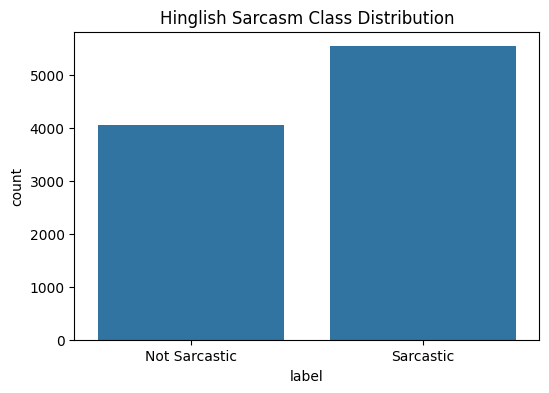

In [6]:
data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data.columns = ["text","label"]
data["label"] = pd.to_numeric(data["label"], errors="coerce")
data = data.dropna(subset=["text","label"]).copy()
data["label"] = data["label"].astype(int)
data["text"] = data["text"].astype(str)

if not set(data["label"].unique()).issubset({0,1}):
    raise ValueError(f"Expected labels 0/1; found {sorted(data['label'].unique())}")

print("Samples:", len(data))
print(data["label"].value_counts().sort_index())
print((data["label"].value_counts(normalize=True).sort_index()*100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=data,x="label")
plt.xticks([0,1],["Not Sarcastic","Sarcastic"])
plt.title("Hinglish Sarcasm Class Distribution")
plt.show()

## 6. Leakage audit and exact-duplicate removal

Exact duplicate normalized tweets are removed before splitting. Examples with the same normalized text but conflicting labels are removed because their label is ambiguous.

In [7]:
def normalize_for_leakage(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+"," ",text)
    text = re.sub(r"@\w+"," ",text)
    text = re.sub(r"#(\w+)",r"\1",text)
    text = re.sub(r"[^a-z0-9\u0900-\u097f\s]"," ",text)
    return re.sub(r"\s+"," ",text).strip()

data["normalized_text"] = data["text"].apply(normalize_for_leakage)

print("Duplicate normalized rows:", int(data.duplicated("normalized_text").sum()))

conflicts = data.groupby("normalized_text")["label"].nunique()
bad = conflicts[conflicts>1].index
print("Conflicting normalized texts:", len(bad))

if len(bad):
    data = data[~data["normalized_text"].isin(bad)].copy()

data = data.drop_duplicates("normalized_text").reset_index(drop=True)
print("Rows after leakage cleanup:", len(data))

Duplicate normalized rows: 663
Conflicting normalized texts: 1
Rows after leakage cleanup: 8929


### Optional near-duplicate audit

This reports highly similar examples. It is disabled for automatic deletion because legitimate social-media tweets can share wording. If the output clearly shows templated copies, set `REMOVE_NEAR_DUPLICATES = True`.

In [8]:
def char_ngrams(text,n=5):
    text=normalize_for_leakage(text)
    return {text[i:i+n] for i in range(max(1,len(text)-n+1))}

def jaccard(a,b):
    return len(a&b)/max(len(a|b),1)

REMOVE_NEAR_DUPLICATES=False
THRESHOLD=0.90

sample=data.sample(min(1500,len(data)),random_state=SEED).reset_index(drop=True)
grams=[char_ngrams(x) for x in sample.text]
hits=[]
for i in range(len(sample)):
    for j in range(i+1,len(sample)):
        s=jaccard(grams[i],grams[j])
        if s>=THRESHOLD: hits.append((i,j,s))

print("Near-duplicate pairs found in audit:",len(hits))
for i,j,s in hits[:10]:
    print("\nSimilarity:",round(s,3))
    print("A:",sample.loc[i,"text"])
    print("B:",sample.loc[j,"text"])

if REMOVE_NEAR_DUPLICATES:
    keep=[]; kept=[]
    for idx,t in tqdm(enumerate(data.text),total=len(data),desc="Filtering near duplicates"):
        g=char_ngrams(t)
        if not any(jaccard(g,x)>=THRESHOLD for x in kept):
            keep.append(idx); kept.append(g)
    data=data.iloc[keep].reset_index(drop=True)
    print("Rows after near-duplicate filtering:",len(data))

Near-duplicate pairs found in audit: 2

Similarity: 0.941
A: Rawalpindi: Pakistan Me World Eleven Cricket Team Ko Khushamdeed Kahtay Hain, Pur Aman Aur Khail Pasand Qaum Maizbani Ko Baytab Hai, DG ISPR
B: Rawalpindi: Pakistan Me World Eleven Cricket Team Ko Khushamdeed Kahtay Hai, Pur Aman Aur Khail Pasand Qaum Maizbani Ko Baytab Hai, DG ISPR:

Similarity: 0.958
A: Ckt News: S Ajmal Sohail khan k BaaD Ab Umar Akmal Aur SharJeel khan Ko Be Wajah Cricket se Door Kiya Ja Raha Hai J Miandaad#AnSaR
B: Ckt News: S Ajmal Sohail khan k BaaD Ab Umar Akmal Aur SharJeel khan Ko Be Wajah Cricket se Door Kiya Ja Raha Hai J Miandaad


## 7. Light Hinglish preprocessing

In [9]:
def clean_text(text):
    text=str(text)
    text=re.sub(r"https?://\S+|www\.\S+"," ",text)
    text=re.sub(r"@\w+"," ",text)
    text=re.sub(r"#(\w+)",r"\1",text)
    text=re.sub(r"(.)\1{3,}",r"\1\1",text)
    return re.sub(r"\s+"," ",text).strip()

data["clean_text"]=data["text"].apply(clean_text)
data=data[data.clean_text.str.len()>0].reset_index(drop=True)
display(data[["text","clean_text","label"]].head(10))

,text,clean_text,label
0,Ckt News: S Ajmal Sohail khan k BaaD Ab Umar A...,Ckt News: S Ajmal Sohail khan k BaaD Ab Umar A...,0
1,Online resources se bahut kuch seekh rahe,Online resources se bahut kuch seekh rahe,0
2,Aab maaf kar dena chahiye-or azad bhi kar do b...,Aab maaf kar dena chahiye-or azad bhi kar do b...,0
3,Bahan k sath-sath biwi ko v nhi mante.Parinam ...,Bahan k sath-sath biwi ko v nhi mante.Parinam ...,0
4,sakta ham talk ke baare mein something else? k...,sakta ham talk ke baare mein something else? k...,0
5,"Isliye public ko isis, triple talaq m uljha k ...","Isliye public ko isis, triple talaq m uljha k ...",0
6,@ViratBharat Raza Murad bahut kaamyab aadmi he...,Raza Murad bahut kaamyab aadmi he. Uski baat s...,1
7,"Oh great, another mirror selfie with new outfit","Oh great, another mirror selfie with new outfit",1
8,"KyunkiYeh India Hai,aurYahan HarTarahki Chhoot...","KyunkiYeh India Hai,aurYahan HarTarahki Chhoot...",0
9,Tumse Koi Pyara Koi Masoom Nahi Hai. @TheAlkaY...,Tumse Koi Pyara Koi Masoom Nahi Hai. AlkaYagni...,0


## 8. Stratified 70/15/15 split

In [10]:
train_df,temp_df=train_test_split(data,test_size=0.30,stratify=data.label,random_state=SEED)
val_df,test_df=train_test_split(temp_df,test_size=0.50,stratify=temp_df.label,random_state=SEED)

print("Train:",len(train_df),"Validation:",len(val_df),"Test:",len(test_df))

Train: 6250 Validation: 1339 Test: 1340


## 9. XLM-RoBERTa embeddings

In [11]:
MODEL_NAME="FacebookAI/xlm-roberta-base"
MAX_LENGTH=96
EMBED_BATCH_SIZE=32

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
xlm_model=AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
for p in xlm_model.parameters(): p.requires_grad=False

def mean_pooling(last_hidden_state,attention_mask):
    mask=attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state*mask).sum(1)/torch.clamp(mask.sum(1),min=1e-9)

def get_xlm_embeddings(texts):
    out=[]
    for start in tqdm(range(0,len(texts),EMBED_BATCH_SIZE),desc="XLM-R"):
        batch=texts[start:start+EMBED_BATCH_SIZE]
        enc=tokenizer(batch,padding=True,truncation=True,max_length=MAX_LENGTH,return_tensors="pt")
        enc={k:v.to(device) for k,v in enc.items()}
        with torch.inference_mode():
            h=xlm_model(**enc).last_hidden_state
            p=mean_pooling(h,enc["attention_mask"])
        out.append(p.cpu().numpy())
    return np.vstack(out).astype(np.float32)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
train_texts=train_df.clean_text.tolist()
val_texts=val_df.clean_text.tolist()
test_texts=test_df.clean_text.tolist()

X_train_xlm=get_xlm_embeddings(train_texts)
X_val_xlm=get_xlm_embeddings(val_texts)
X_test_xlm=get_xlm_embeddings(test_texts)

print(X_train_xlm.shape,X_val_xlm.shape,X_test_xlm.shape)

XLM-R:   0%|          | 0/196 [00:00<?, ?it/s]

XLM-R:   0%|          | 0/42 [00:00<?, ?it/s]

XLM-R:   0%|          | 0/42 [00:00<?, ?it/s]

(6250, 768) (1339, 768) (1340, 768)


## 10. Multilingual Twitter sentiment features

In [13]:
SENTIMENT_MODEL="cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual"

sent_tokenizer=AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
sent_model=AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL).to(device).eval()
for p in sent_model.parameters(): p.requires_grad=False

print(sent_model.config.id2label)

def get_sentiment_features(texts):
    all_probs=[]
    for start in tqdm(range(0,len(texts),EMBED_BATCH_SIZE),desc="Sentiment"):
        batch=texts[start:start+EMBED_BATCH_SIZE]
        enc=sent_tokenizer(batch,padding=True,truncation=True,max_length=MAX_LENGTH,return_tensors="pt")
        enc={k:v.to(device) for k,v in enc.items()}
        with torch.inference_mode():
            probs=torch.softmax(sent_model(**enc).logits,dim=-1)
        all_probs.append(probs.cpu().numpy())
    probs=np.vstack(all_probs).astype(np.float32)
    polarity=(probs[:,2]-probs[:,0]).reshape(-1,1)
    return np.hstack([probs,polarity]).astype(np.float32)

S_train=get_sentiment_features(train_texts)
S_val=get_sentiment_features(val_texts)
S_test=get_sentiment_features(test_texts)

config.json:   0%|          | 0.00/982 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

...

Sentiment:   0%|          | 0/196 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Sentiment:   0%|          | 0/42 [00:00<?, ?it/s]

Sentiment:   0%|          | 0/42 [00:00<?, ?it/s]

## 11. Fuse 768 XLM-R + 4 sentiment features

In [14]:
X_train=np.hstack([X_train_xlm,S_train]).astype(np.float32)
X_val=np.hstack([X_val_xlm,S_val]).astype(np.float32)
X_test=np.hstack([X_test_xlm,S_test]).astype(np.float32)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled=scaler.transform(X_val).astype(np.float32)
X_test_scaled=scaler.transform(X_test).astype(np.float32)

y_train=train_df.label.to_numpy(dtype=np.float32)
y_val=val_df.label.to_numpy(dtype=np.float32)
y_test=test_df.label.to_numpy(dtype=np.float32)

print("Final feature dimension:",X_train_scaled.shape[1])
assert X_train_scaled.shape[1]==772

Final feature dimension: 772


## 12. Optuna DNN + 5-fold stratified CV

Optuna maximizes mean **F1** across five folds on the training partition only. The test set is never used for tuning.

In [15]:
def build_trial_model(trial,input_dim):
    n_layers=trial.suggest_int("n_layers",1,3)
    layers=[]; in_features=input_dim
    for i in range(n_layers):
        hidden=trial.suggest_categorical(f"hidden_{i}",[64,128,256,512])
        dropout=trial.suggest_float(f"dropout_{i}",0.10,0.50)
        layers += [nn.Linear(in_features,hidden),nn.BatchNorm1d(hidden),nn.ReLU(),nn.Dropout(dropout)]
        in_features=hidden
    layers.append(nn.Linear(in_features,1))
    return nn.Sequential(*layers)

N_TRIALS=13
N_SPLITS=5
CV_EPOCHS=15
CV_PATIENCE=3

skf=StratifiedKFold(n_splits=N_SPLITS,shuffle=True,random_state=SEED)

def objective(trial):

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    lr = trial.suggest_float(
        "learning_rate",
        1e-4,
        3e-3,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-7,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW"]
    )

    scores = []

    for fold, (tr, va) in enumerate(
        skf.split(X_train_scaled, y_train)
    ):

        # -------------------------
        # Build model
        # -------------------------

        net = build_trial_model(
            trial,
            X_train_scaled.shape[1]
        ).to(device)

        # -------------------------
        # Datasets
        # -------------------------

        X_tr = torch.from_numpy(
            X_train_scaled[tr]
        ).float()

        y_tr = torch.from_numpy(
            y_train[tr]
        ).float()

        X_va = torch.from_numpy(
            X_train_scaled[va]
        ).float()

        y_va = torch.from_numpy(
            y_train[va]
        ).float()

        tr_ds = TensorDataset(
            X_tr,
            y_tr
        )

        va_ds = TensorDataset(
            X_va,
            y_va
        )

        tr_loader = DataLoader(
            tr_ds,
            batch_size=batch_size,
            shuffle=True
        )

        va_loader = DataLoader(
            va_ds,
            batch_size=batch_size,
            shuffle=False
        )

        # -------------------------
        # Class weights
        # -------------------------

        w = compute_class_weight(
            class_weight="balanced",
            classes=np.array([0, 1]),
            y=y_train[tr].astype(int)
        )

        w = torch.tensor(
            w,
            dtype=torch.float32,
            device=device
        )

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=w[1] / w[0]
        )

        # -------------------------
        # Optimizer
        # -------------------------

        if optimizer_name == "Adam":

            opt = torch.optim.Adam(
                net.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

        else:

            opt = torch.optim.AdamW(
                net.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

        # -------------------------
        # Training
        # -------------------------

        best_f1 = 0.0
        wait = 0

        for epoch in range(CV_EPOCHS):

            net.train()

            for xb, yb in tr_loader:

                xb = xb.to(device)
                yb = yb.to(device)

                opt.zero_grad()

                # IMPORTANT:
                # Model output: [batch, 1]
                # Labels:       [batch]
                # Convert output to [batch]
                logits = net(xb).squeeze(1)

                loss = criterion(
                    logits,
                    yb
                )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    net.parameters(),
                    1.0
                )

                opt.step()

            # -------------------------
            # Validation
            # -------------------------

            net.eval()

            probs = []

            with torch.inference_mode():

                for xb, _ in va_loader:

                    logits = net(
                        xb.to(device)
                    ).squeeze(1)

                    batch_probs = torch.sigmoid(
                        logits
                    ).cpu().numpy()

                    probs.extend(
                        batch_probs.tolist()
                    )

            probs = np.asarray(
                probs,
                dtype=np.float32
            ).reshape(-1)

            preds = (
                probs >= 0.5
            ).astype(int)

            score = f1_score(
                y_train[va],
                preds,
                zero_division=0
            )

            # -------------------------
            # Early stopping
            # -------------------------

            if score > best_f1:

                best_f1 = score
                wait = 0

            else:

                wait += 1

            if wait >= CV_PATIENCE:
                break

        # -------------------------
        # Fold result
        # -------------------------

        scores.append(best_f1)

        trial.report(
            float(np.mean(scores)),
            step=fold
        )

        if trial.should_prune():

            raise optuna.TrialPruned()

    return float(
        np.mean(scores)
    )

In [16]:
print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape)
print("y_train dtype:", y_train.dtype)
print("Classes:", np.unique(y_train))

X_train_scaled: (6250, 772)
y_train: (6250,)
y_train dtype: float32
Classes: [0. 1.]


In [17]:
study=optuna.create_study(
    direction="maximize",
    study_name="hinglish_sarcasm_9594",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5,n_warmup_steps=2)
)
study.optimize(objective,n_trials=N_TRIALS,show_progress_bar=True)

print("Best 5-fold CV F1:",study.best_value)
print("\nBest parameters:")
for k,v in study.best_params.items(): print(k,":",v)

[I 2026-09-03 17:57:51,146] A new study created in memory with name: hinglish_sarcasm_9594


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-03 17:58:22,529] Trial 0 finished with value: 0.9363125408494174 and parameters: {'batch_size': 64, 'learning_rate': 0.0007661100707771367, 'weight_decay': 4.20798866960663e-07, 'optimizer': 'Adam', 'n_layers': 3, 'hidden_0': 512, 'dropout_0': 0.4329770563201687, 'hidden_1': 512, 'dropout_1': 0.3099025726528951, 'hidden_2': 256, 'dropout_2': 0.21685785941408728}. Best is trial 0 with value: 0.9363125408494174.
[I 2026-09-03 17:58:41,374] Trial 1 finished with value: 0.934949179075517 and parameters: {'batch_size': 128, 'learning_rate': 0.00019721610970574026, 'weight_decay': 1.1400863701127326e-05, 'optimizer': 'Adam', 'n_layers': 2, 'hidden_0': 512, 'dropout_0': 0.4233589392465845, 'hidden_1': 256, 'dropout_1': 0.14881529393791154}. Best is trial 0 with value: 0.9363125408494174.
[I 2026-09-03 17:58:52,861] Trial 2 finished with value: 0.9342479578001488 and parameters: {'batch_size': 128, 'learning_rate': 0.00024112898115291975, 'weight_decay': 4.467752817973903e-05, 'opti

## 13. Optuna result inspection

,number,value,state
14,14,0.938029,PRUNED
10,10,0.937099,PRUNED
6,6,0.936491,PRUNED
0,0,0.936313,COMPLETE
7,7,0.935952,COMPLETE
12,12,0.935534,COMPLETE
3,3,0.935166,COMPLETE
13,13,0.935100,COMPLETE
1,1,0.934949,COMPLETE
11,11,0.934888,COMPLETE


/tmp/ipykernel_1900/3211362028.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study); plt.show()


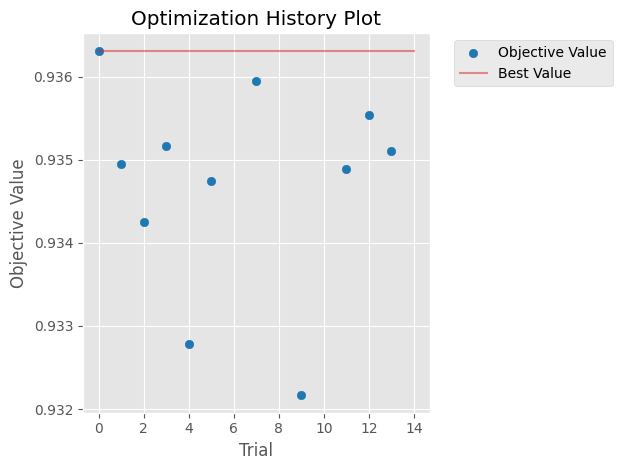

/tmp/ipykernel_1900/3211362028.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study); plt.show()


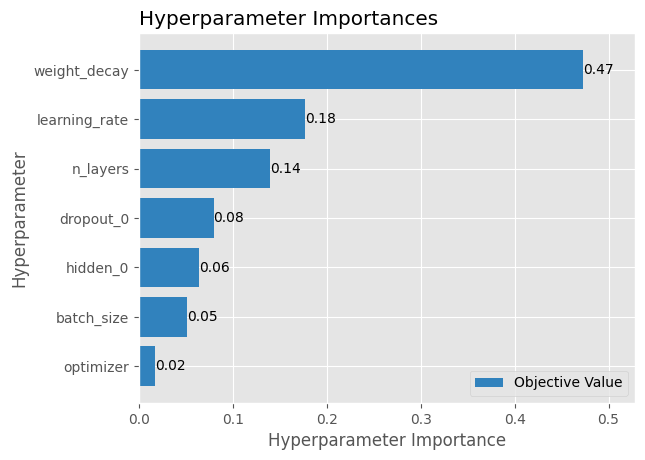

In [18]:
display(study.trials_dataframe(attrs=["number","value","state"]).sort_values("value",ascending=False).head(10))
try:
    optuna.visualization.matplotlib.plot_optimization_history(study); plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study); plt.show()
except Exception as e:
    print("Plotting skipped:",e)

## 14. Build and train final model

In [20]:
best = study.best_params

def build_best_model(input_dim):

    layers = []
    in_features = input_dim

    for i in range(best["n_layers"]):

        hidden = best[f"hidden_{i}"]
        dropout = best[f"dropout_{i}"]

        layers += [
            nn.Linear(in_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        ]

        in_features = hidden

    layers.append(
        nn.Linear(in_features, 1)
    )

    return nn.Sequential(*layers)


# =========================
# Build final model
# =========================

final_model = build_best_model(
    X_train_scaled.shape[1]
).to(device)


# =========================
# Training dataset
# =========================

X_train_tensor = torch.from_numpy(
    X_train_scaled
).float()

y_train_tensor = torch.from_numpy(
    y_train
).float().reshape(-1)

train_ds = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_ds,
    batch_size=best["batch_size"],
    shuffle=True
)


# =========================
# Loss
# =========================

w = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train.astype(int)
)

w = torch.tensor(
    w,
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=w[1] / w[0]
)


# =========================
# Optimizer
# =========================

if best["optimizer"] == "Adam":

    optimizer = torch.optim.Adam(
        final_model.parameters(),
        lr=best["learning_rate"],
        weight_decay=best["weight_decay"]
    )

else:

    optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=best["learning_rate"],
        weight_decay=best["weight_decay"]
    )


# =========================
# Final training
# =========================

FINAL_EPOCHS = 30

loss_history = []

for epoch in range(1, FINAL_EPOCHS + 1):

    final_model.train()

    total_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        # Model output: [batch, 1]
        # Labels:       [batch]
        # Convert output to [batch]
        logits = final_model(xb).squeeze(1)

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    epoch_loss = (
        total_loss / len(train_loader)
    )

    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch:02d}/{FINAL_EPOCHS} | "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch 01/30 | Loss: 0.2199
Epoch 02/30 | Loss: 0.1526
Epoch 03/30 | Loss: 0.1325
Epoch 04/30 | Loss: 0.1256
Epoch 05/30 | Loss: 0.1024
Epoch 06/30 | Loss: 0.0984
Epoch 07/30 | Loss: 0.0905
Epoch 08/30 | Loss: 0.0839
Epoch 09/30 | Loss: 0.0706
Epoch 10/30 | Loss: 0.0684
Epoch 11/30 | Loss: 0.0653
Epoch 12/30 | Loss: 0.0490
Epoch 13/30 | Loss: 0.0553
Epoch 14/30 | Loss: 0.0541
Epoch 15/30 | Loss: 0.0416
Epoch 16/30 | Loss: 0.0371
Epoch 17/30 | Loss: 0.0344
Epoch 18/30 | Loss: 0.0331
Epoch 19/30 | Loss: 0.0307
Epoch 20/30 | Loss: 0.0323
Epoch 21/30 | Loss: 0.0250
Epoch 22/30 | Loss: 0.0307
Epoch 23/30 | Loss: 0.0264
Epoch 24/30 | Loss: 0.0206
Epoch 25/30 | Loss: 0.0261
Epoch 26/30 | Loss: 0.0266
Epoch 27/30 | Loss: 0.0192
Epoch 28/30 | Loss: 0.0199
Epoch 29/30 | Loss: 0.0174
Epoch 30/30 | Loss: 0.0173


## 15. Final untouched test evaluation

In [21]:
test_ds=TensorDataset(torch.from_numpy(X_test_scaled),torch.from_numpy(y_test))
test_loader=DataLoader(test_ds,batch_size=best["batch_size"],shuffle=False)

final_model.eval(); test_probs=[]
with torch.inference_mode():
    for xb,_ in test_loader:
        test_probs.extend(torch.sigmoid(final_model(xb.to(device))).cpu().numpy())

test_probs=np.asarray(test_probs).reshape(-1)
test_preds=(test_probs>=0.5).astype(int)

metrics={
    "Accuracy":accuracy_score(y_test,test_preds),
    "Precision":precision_score(y_test,test_preds,zero_division=0),
    "Recall":recall_score(y_test,test_preds,zero_division=0),
    "F1":f1_score(y_test,test_preds,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,test_probs)
}

print("FINAL TEST RESULTS")
for k,v in metrics.items(): print(f"{k:10s}: {v:.4f}")

print("\n",classification_report(y_test,test_preds,target_names=["Not Sarcastic","Sarcastic"],digits=4,zero_division=0))

FINAL TEST RESULTS
Accuracy  : 0.9410
Precision : 0.9544
Recall    : 0.9376
F1        : 0.9459
ROC-AUC   : 0.9887

                precision    recall  f1-score   support

Not Sarcastic     0.9253    0.9453    0.9352       603
    Sarcastic     0.9544    0.9376    0.9459       737

     accuracy                         0.9410      1340
    macro avg     0.9399    0.9414    0.9406      1340
 weighted avg     0.9413    0.9410    0.9411      1340



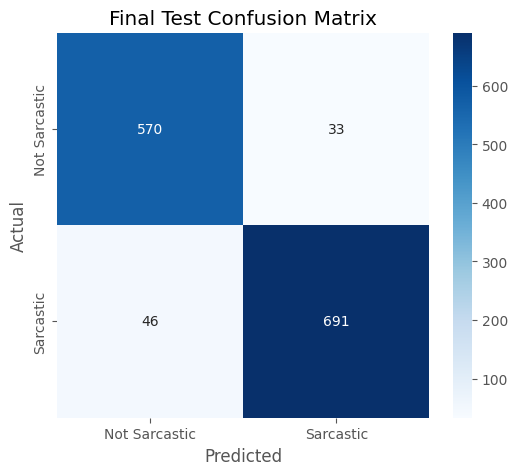

In [22]:
cm=confusion_matrix(y_test,test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Not Sarcastic","Sarcastic"],
            yticklabels=["Not Sarcastic","Sarcastic"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Final Test Confusion Matrix")
plt.show()

## 16. Real-time prediction

In [23]:
def predict_tweet(text,threshold=0.5):
    cleaned=clean_text(text)
    xlm=get_xlm_embeddings([cleaned])
    sent=get_sentiment_features([cleaned])
    fused=np.hstack([xlm,sent]).astype(np.float32)
    fused=scaler.transform(fused).astype(np.float32)
    final_model.eval()
    with torch.inference_mode():
        p=torch.sigmoid(final_model(torch.from_numpy(fused).to(device))).item()
    return {"tweet":text,"prediction":"Sarcastic" if p>=threshold else "Not Sarcastic","sarcasm_probability":round(p,4)}

print(predict_tweet("Wah bhai kya zabardast service hai, pura din wait karwaya."))

XLM-R:   0%|          | 0/1 [00:00<?, ?it/s]

Sentiment:   0%|          | 0/1 [00:00<?, ?it/s]

{'tweet': 'Wah bhai kya zabardast service hai, pura din wait karwaya.', 'prediction': 'Sarcastic', 'sarcasm_probability': 0.9287}


## 17. Save model, scaler, Optuna configuration, and test predictions

In [24]:
OUTPUT_DIR="/content/hinglish_sarcasm_9594_optuna_model"
os.makedirs(OUTPUT_DIR,exist_ok=True)

torch.save(final_model.state_dict(),os.path.join(OUTPUT_DIR,"sarcasm_dnn_optuna.pth"))
joblib.dump(scaler,os.path.join(OUTPUT_DIR,"feature_scaler.pkl"))

config={
    "dataset":DATA_PATH,
    "xlm_model":MODEL_NAME,
    "sentiment_model":SENTIMENT_MODEL,
    "input_dimension":int(X_train_scaled.shape[1]),
    "cv_folds":N_SPLITS,
    "optuna_trials":N_TRIALS,
    "optimization_metric":"F1",
    "best_cv_f1":float(study.best_value),
    "best_params":study.best_params,
    "test_metrics":{k:float(v) for k,v in metrics.items()},
    "label_mapping":{"0":"Not Sarcastic","1":"Sarcastic"}
}
with open(os.path.join(OUTPUT_DIR,"config.json"),"w") as f: json.dump(config,f,indent=2,default=str)

pred_df=test_df[["text","clean_text","label"]].copy()
pred_df["predicted_label"]=test_preds
pred_df["sarcasm_probability"]=test_probs
pred_df.to_csv(os.path.join(OUTPUT_DIR,"test_predictions.csv"),index=False)

print("Saved artifacts:")
for f in sorted(os.listdir(OUTPUT_DIR)): print(" -",f)

Saved artifacts:
 - config.json
 - feature_scaler.pkl
 - sarcasm_dnn_optuna.pth
 - test_predictions.csv


## Final reporting rule

Use the **final untouched test metrics** in your resume/project report. Do not tune hyperparameters or thresholds against the test set just to reach 90% or 98%.

A strong project description is:

> Built a Hinglish sarcasm detection pipeline using XLM-RoBERTa contextual embeddings and multilingual Twitter sentiment features, with an Optuna-optimized DNN classifier and stratified 5-fold cross-validation.

If the untouched test set genuinely gives 90%+ accuracy, report it together with F1, precision, recall and ROC-AUC.